# 03 — Spatial patterns

**Purpose:** Visualize LISA HH (High-High) and LL (Low-Low) clusters, examine distribution of HH frequency across seeds, and run connected-component analysis for hotspot stability. Observation-level cross-seed stability requires a fixed test set across runs.

## Imports and path setup

In [27]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from thesis_layout import (
    apply_thesis_plot_style,
    display_dataset_name,
    RAW_RESULTS,
    thesis_output_dirs,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
apply_thesis_plot_style()
from IPython.display import display
import seaborn as sns
from sklearn.decomposition import PCA

from analysis.io_utils import get_run_dirs
from analysis.knn_defaults import K_NN_BY_DATASET
from analysis.preprocessing import get_transformed_test_features
from analysis.run_analysis import (
    load_meta,
    load_P_test,
    load_split,
    run_spatial,
    select_rashomon_global,
    mean_variance
)
from scipy.sparse.csgraph import connected_components as sparse_connected_components
from analysis.spatial import extract_hh_components
from analysis.stability import (
    hh_jaccard_matrix,
    hh_point_level_support_metrics,
    hh_selection_frequency,
    summarize_hh_stability
)

RESULTS_DEFAULT_DIR = RAW_RESULTS
RESULTS_FIXED_TEST_DIR = ROOT / "results_fixed_test"
TABLE_DIR, FIG_DIR = thesis_output_dirs("nb03")
FORCE_RECOMPUTE = False
CACHE_VERSION = "v1"
CACHE_DIR = ROOT / "thesis_outputs" / "cache" / "notebooks"
CACHE_DIR.mkdir(parents=True, exist_ok=True)



## All datasets: compute HH masks across seeds

For each dataset and run we compute spatial analysis (Moran's I, LISA) and collect HH_mask, LL_mask, and pointwise variance.

Set `DATASET` to `compas`, `german`, or `adult` and rerun this notebook to regenerate dataset-specific fixed-test spatial outputs. The thesis mainly uses the COMPAS fixed-test stability results.

In [28]:
DATASET = "german"
K = 25
k_nn = K_NN_BY_DATASET[DATASET]
USE_FIXED_TEST = True  # Required for valid observation-level cross-seed stability.

RESULTS_DIR = RESULTS_FIXED_TEST_DIR if USE_FIXED_TEST else RESULTS_DEFAULT_DIR
dataset_dir = RESULTS_DIR / DATASET
run_dirs = get_run_dirs(dataset_dir)
if not run_dirs:
    raise SystemExit(f"No runs found in {dataset_dir}. "
                     f"Run fixed-test training first: run_training_pipeline_fixed_test.py")

_results_tag = f"{DATASET}_{'fixed' if USE_FIXED_TEST else 'default'}"


_metrics_path = CACHE_DIR / f"nb03_spatial_metrics_{_results_tag}_{CACHE_VERSION}.parquet"
_masks_path = CACHE_DIR / f"nb03_spatial_masks_{_results_tag}_{CACHE_VERSION}.parquet"


def compute_spatial_analysis():
    metrics_rows = []
    mask_rows = []
    for run_dir in run_dirs:
        split = load_split(run_dir)
        test_idx = np.asarray(split["test"], dtype=int)
        n_cand = len(load_meta(run_dir))
        K_actual = min(K, n_cand)
        X_test = get_transformed_test_features(run_dir, DATASET)
        res = run_spatial(run_dir, X_test, K=K_actual, k=k_nn)
        P_test = load_P_test(run_dir)
        idx = select_rashomon_global(run_dir, K=K_actual)
        mean_var = mean_variance(P_test[idx], ddof=0)
        hh_mask = np.asarray(res["HH_mask"], dtype=bool)
        conflict_hh = res.get("conflict_HH_mask")
        if conflict_hh is None:
            conflict_hh = np.zeros(len(hh_mask), dtype=bool)
        else:
            conflict_hh = np.asarray(conflict_hh, dtype=bool)
        metrics_rows.append({
            "run_dir": run_dir.name,
            "moran_i": res["moran_i"],
            "mean_variance": float(mean_var),
            "n_hh": int(np.sum(hh_mask)),
            "n_ll": int(np.sum(res.get("LL_mask", np.zeros_like(hh_mask)))),
            "conflict_moran_i": res.get("conflict_moran_i", np.nan),
            "conflict_n_hh": int(res.get("conflict_n_hh", 0)),
        })
        for point_idx, (is_hh, is_conf, test_row) in enumerate(
            zip(hh_mask, conflict_hh, test_idx)
        ):
            mask_rows.append({
                "run_dir": run_dir.name,
                "point_idx": int(point_idx),
                "test_row_idx": int(test_row),
                "is_hh": bool(is_hh),
                "is_conflict_hh": bool(is_conf),
            })
    metrics_df = pd.DataFrame(metrics_rows)
    masks_df = pd.DataFrame(mask_rows)
    metrics_df.to_parquet(_metrics_path, index=False)
    masks_df.to_parquet(_masks_path, index=False)
    return metrics_df


def load_spatial_analysis():
    if (
        not FORCE_RECOMPUTE
        and _metrics_path.is_file()
        and _masks_path.is_file()
    ):
        return pd.read_parquet(_metrics_path), pd.read_parquet(_masks_path)
    compute_spatial_analysis()
    return pd.read_parquet(_metrics_path), pd.read_parquet(_masks_path)


df_spatial_runs, df_spatial_masks = load_spatial_analysis()

# Rebuild spatial_by_run for downstream cells
spatial_by_run = []
for run_dir_name, mgrp in df_spatial_masks.groupby("run_dir"):
    mgrp = mgrp.sort_values("point_idx")
    metrics = df_spatial_runs.loc[df_spatial_runs["run_dir"] == run_dir_name].iloc[0]
    spatial_by_run.append({
        "run_dir": run_dir_name,
        "moran_i": metrics["moran_i"],
        "mean_variance": metrics["mean_variance"],
        "HH_mask": mgrp["is_hh"].to_numpy(dtype=bool),
        "conflict_HH_mask": mgrp["is_conflict_hh"].to_numpy(dtype=bool),
        "test_idx": mgrp["test_row_idx"].to_numpy(dtype=int),
        "n_hh": int(metrics["n_hh"]),
    })

test_idx_ref = spatial_by_run[0]["test_idx"] if spatial_by_run else None
test_indices_aligned = all(
    np.array_equal(test_idx_ref, r["test_idx"]) for r in spatial_by_run
)
print(f"Computed spatial metrics for {len(spatial_by_run)} runs.")
print(f"Test indices aligned across runs: {test_indices_aligned}")
if not test_indices_aligned:
    raise ValueError(
        "Observation-level HH stability is invalid because test sets differ across runs. "
        "Use fixed-test artifacts (results_fixed_test/...)."
    )


def ensure_spatial_weights(run_entry, run_dir_path):
    """Load kNN weights W for one run when a plot/diagnostic needs them."""
    if "W" in run_entry:
        return run_entry["W"]
    n_cand = len(load_meta(run_dir_path))
    K_actual = min(K, n_cand)
    X_test = get_transformed_test_features(run_dir_path, DATASET)
    res = run_spatial(run_dir_path, X_test, K=K_actual, k=k_nn)
    run_entry["W"] = res["W"]
    return run_entry["W"]


Computed spatial metrics for 10 runs.
Test indices aligned across runs: True


## HH stability analysis and visualizations

### Thesis-facing table: HH connected components

Per-run component statistics and the aggregated thesis row (Table `hh_component_summary`) are shown below. Detailed stability plots follow in this section.

Compute HH selection frequency across seeds, Jaccard overlap matrix, stability summary, and save figures (frequency scatter, Jaccard heatmap, HH location in feature space) plus component summary table.



Point-level HH support metrics (N=200 fixed-test points):
  HH support size |{i : f_i > 0}| / N = 0.1050
  On HH support only (f_i > 0): mean f_i = 0.1762, median = 0.1000
  Bucket counts on support — (0,0.2], (0.2,0.5], (0.5,0.8], (0.8,1]: 18 2 1 0
  Bucket fractions of |support|: 0.857, 0.095, 0.048, 0.000
  Core-to-support |{i : f_i >= 0.5}| / |{i : f_i > 0}| = 0.0952
Representative run (median HH count): index=3, run=seed=3, n_HH=4


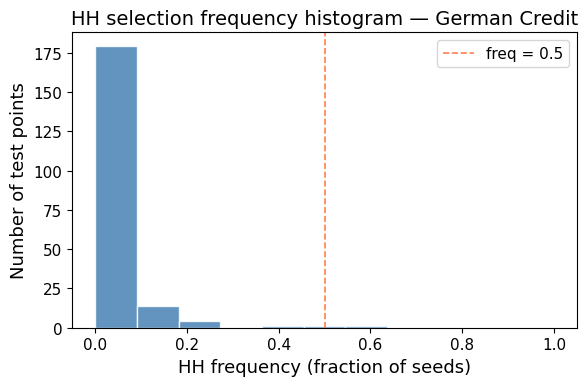

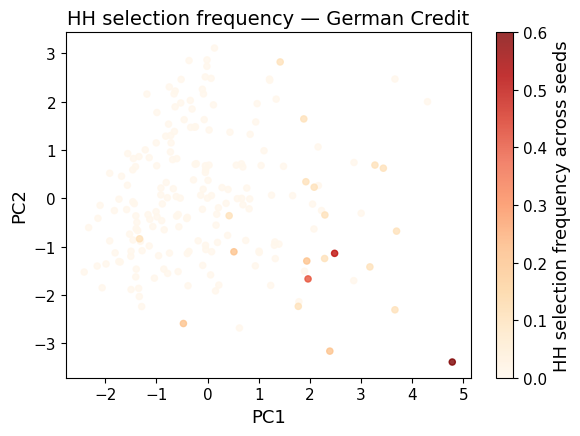

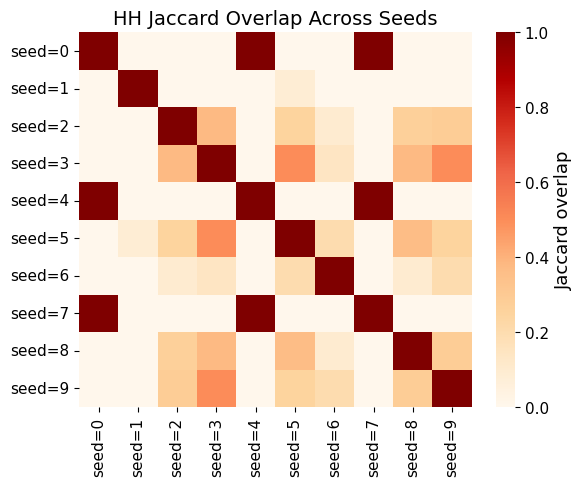

,run,n_components,max_component_size,mean_hh_fraction,mean_jaccard,min_jaccard,max_jaccard,hh_support_size,hh_support_mean_f,hh_support_median_f,hh_support_bucket_00_02,hh_support_bucket_02_05,hh_support_bucket_05_08,hh_support_bucket_08_10,hh_support_bucket_00_02_frac,hh_support_bucket_02_05_frac,hh_support_bucket_05_08_frac,hh_support_bucket_08_10_frac,hh_core_to_support_ratio
0,seed=0,0,0,0.0185,0.161866,0.0,1.0,0.105,0.17619,0.1,18.0,2.0,1.0,0.0,0.857143,0.095238,0.047619,0.0,0.095238
1,seed=1,1,5,0.0185,0.161866,0.0,1.0,0.105,0.17619,0.1,18.0,2.0,1.0,0.0,0.857143,0.095238,0.047619,0.0,0.095238
2,seed=2,1,7,0.0185,0.161866,0.0,1.0,0.105,0.17619,0.1,18.0,2.0,1.0,0.0,0.857143,0.095238,0.047619,0.0,0.095238
3,seed=3,0,0,0.0185,0.161866,0.0,1.0,0.105,0.17619,0.1,18.0,2.0,1.0,0.0,0.857143,0.095238,0.047619,0.0,0.095238
4,seed=4,0,0,0.0185,0.161866,0.0,1.0,0.105,0.17619,0.1,18.0,2.0,1.0,0.0,0.857143,0.095238,0.047619,0.0,0.095238
5,seed=5,1,8,0.0185,0.161866,0.0,1.0,0.105,0.17619,0.1,18.0,2.0,1.0,0.0,0.857143,0.095238,0.047619,0.0,0.095238
6,seed=6,0,0,0.0185,0.161866,0.0,1.0,0.105,0.17619,0.1,18.0,2.0,1.0,0.0,0.857143,0.095238,0.047619,0.0,0.095238
7,seed=7,0,0,0.0185,0.161866,0.0,1.0,0.105,0.17619,0.1,18.0,2.0,1.0,0.0,0.857143,0.095238,0.047619,0.0,0.095238
8,seed=8,1,7,0.0185,0.161866,0.0,1.0,0.105,0.17619,0.1,18.0,2.0,1.0,0.0,0.857143,0.095238,0.047619,0.0,0.095238
9,seed=9,0,0,0.0185,0.161866,0.0,1.0,0.105,0.17619,0.1,18.0,2.0,1.0,0.0,0.857143,0.095238,0.047619,0.0,0.095238


Thesis table: HH connected-component summary


,Dataset,Mean n components,Mean max component size,Median max component size,Max (over runs)
0,German Credit,0.40,2.70,0,8


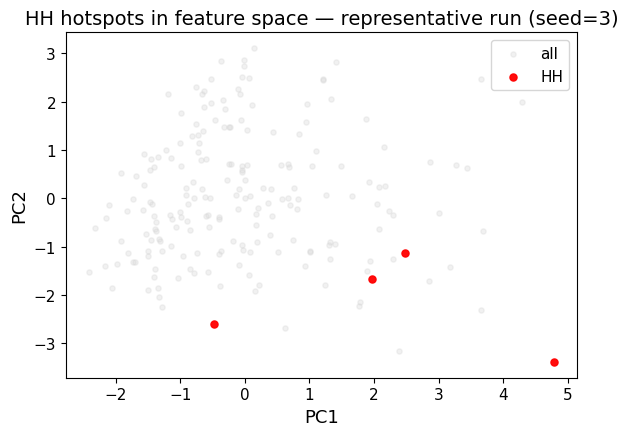

In [29]:
# Part 1: HH stability
hh_masks = [r["HH_mask"] for r in spatial_by_run]
freq = hh_selection_frequency(hh_masks)
J = hh_jaccard_matrix(hh_masks)
stability_summary = summarize_hh_stability(hh_masks)

spm = hh_point_level_support_metrics(freq)
n_test = len(freq)
print(f"\nPoint-level HH support metrics (N={n_test} fixed-test points):")
print(f"  HH support size |{{i : f_i > 0}}| / N = {spm['hh_support_size']:.4f}")
print(
    f"  On HH support only (f_i > 0): mean f_i = {spm['hh_support_mean_f']:.4f}, "
    f"median = {spm['hh_support_median_f']:.4f}"
)
print(
    "  Bucket counts on support — (0,0.2], (0.2,0.5], (0.5,0.8], (0.8,1]:",
    int(spm["hh_support_bucket_00_02"]),
    int(spm["hh_support_bucket_02_05"]),
    int(spm["hh_support_bucket_05_08"]),
    int(spm["hh_support_bucket_08_10"]),
)
print(
    "  Bucket fractions of |support|:",
    f"{spm['hh_support_bucket_00_02_frac']:.3f},",
    f"{spm['hh_support_bucket_02_05_frac']:.3f},",
    f"{spm['hh_support_bucket_05_08_frac']:.3f},",
    f"{spm['hh_support_bucket_08_10_frac']:.3f}",
)
print(
    f"  Core-to-support |{{i : f_i >= 0.5}}| / |{{i : f_i > 0}}| = "
    f"{spm['hh_core_to_support_ratio']:.4f}"
)

# X_test from first run for plotting (same test size across runs)
run_dir0 = run_dirs[0]
X_test = get_transformed_test_features(run_dir0, DATASET)
if hasattr(X_test, "values"):
    X_plot = np.asarray(X_test.values, dtype=float)
else:
    X_plot = np.asarray(X_test, dtype=float)
n_features = X_plot.shape[1]

if n_features == 2:
    coords = X_plot
elif n_features == 1:
    coords = np.column_stack([X_plot.ravel(), np.zeros(X_plot.shape[0])])
else:
    pca = PCA(n_components=2, svd_solver="full").fit(X_plot)
    coords = pca.transform(X_plot)

# --- Representative run selection (median HH count) ---
n_hh_counts = np.array([int(np.sum(r["HH_mask"])) for r in spatial_by_run])
median_hh = np.median(n_hh_counts)
rep_idx = int(np.argmin(np.abs(n_hh_counts - median_hh)))
print(f"Representative run (median HH count): index={rep_idx}, "
      f"run={spatial_by_run[rep_idx]['run_dir']}, n_HH={n_hh_counts[rep_idx]}")

# Part 2A-hist: HH frequency histogram
fig_hist, ax_hist = plt.subplots(figsize=(6, 4))
ax_hist.hist(freq, bins=np.linspace(0, 1, 12), color="steelblue", edgecolor="white", alpha=0.85)
ax_hist.set_xlabel("HH frequency (fraction of seeds)", fontsize=13)
ax_hist.set_ylabel("Number of test points", fontsize=13)
ax_hist.set_title(f"HH selection frequency histogram — {display_dataset_name(DATASET)}", fontsize=14)
ax_hist.tick_params(axis="both", labelsize=11)
ax_hist.axvline(0.5, color="coral", ls="--", lw=1.2, label="freq = 0.5")
ax_hist.legend(fontsize=11)
fig_hist.tight_layout()
fig_hist.savefig(FIG_DIR / f"hh_freq_histogram_{DATASET}.pdf", bbox_inches="tight")
plt.show()

# Part 2A: HH frequency visualization
order = np.argsort(freq)

plt.figure(figsize=(6, 4.5))

sc = plt.scatter(
    coords[order, 0],
    coords[order, 1],
    c=freq[order],
    cmap="OrRd",
    s=20,
    alpha=0.8,
)

cbar = plt.colorbar(sc)
cbar.set_label("HH selection frequency across seeds", fontsize=13)
cbar.ax.tick_params(labelsize=11)

plt.xlabel("PC1" if n_features > 2 else "Feature 1", fontsize=13)
plt.ylabel("PC2" if n_features > 2 else "Feature 2", fontsize=13)
plt.title(f"HH selection frequency — {display_dataset_name(DATASET)}", fontsize=14)

plt.tick_params(axis="both", labelsize=11)

plt.tight_layout()
plt.savefig(FIG_DIR / f"hh_stability_freq_{DATASET}.pdf", bbox_inches="tight")
plt.show()

# Part 2B: Jaccard heatmap
run_labels = [r["run_dir"] for r in spatial_by_run]
fig_jacc, ax_jacc = plt.subplots(figsize=(6, 5))
sns.heatmap(
    J,
    xticklabels=run_labels,
    yticklabels=run_labels,
    annot=False,
    cmap="OrRd",
    ax=ax_jacc,
)
ax_jacc.set_title("HH Jaccard Overlap Across Seeds", fontsize=14)
ax_jacc.tick_params(axis="both", labelsize=11)
cbar_jacc = ax_jacc.collections[0].colorbar
cbar_jacc.set_label("Jaccard overlap", fontsize=13)
cbar_jacc.ax.tick_params(labelsize=11)
fig_jacc.tight_layout()
fig_jacc.savefig(FIG_DIR / f"hh_jaccard_heatmap_{DATASET}.pdf")
plt.show()

# Part 3: Component summary + stability metrics
component_stats = []
for r in spatial_by_run:
    lisa_df = pd.DataFrame({"cluster": np.where(r["HH_mask"], "HH", "NS")})
    W = ensure_spatial_weights(r, dataset_dir / r["run_dir"])
    W = W.to_sparse() if hasattr(W, "to_sparse") else W.sparse
    _, components = extract_hh_components(lisa_df, W, min_size=5)
    n_comp = len(components)
    max_size = max(len(inds) for inds in components.values()) if components else 0
    component_stats.append({"run": r["run_dir"], "n_components": n_comp, "max_component_size": max_size})

hh_component_summary = pd.DataFrame(component_stats)
for k, v in stability_summary.items():
    hh_component_summary[k] = v
hh_component_summary.to_csv(TABLE_DIR / f"hh_component_summary_{DATASET}.csv", index=False)
display(hh_component_summary)

thesis_hh_component_tbl = pd.DataFrame([{
    "Dataset": display_dataset_name(DATASET),
    "Mean n components": f"{hh_component_summary['n_components'].mean():.2f}",
    "Mean max component size": f"{hh_component_summary['max_component_size'].mean():.2f}",
    "Median max component size": f"{hh_component_summary['max_component_size'].median():.0f}",
    "Max (over runs)": f"{hh_component_summary['max_component_size'].max():.0f}",
}])
print("Thesis table: HH connected-component summary")
display(thesis_hh_component_tbl)

# Part 4: HH location in feature space (representative run)
r0 = spatial_by_run[rep_idx]
HH_mask_rep = r0["HH_mask"]
plt.figure(figsize=(6, 4.5))
plt.scatter(coords[~HH_mask_rep, 0], coords[~HH_mask_rep, 1], c="lightgray", s=14, alpha=0.30, label="all")
plt.scatter(coords[HH_mask_rep, 0], coords[HH_mask_rep, 1], c="red", s=26, alpha=0.95, label="HH")
plt.xlabel("PC1" if n_features > 2 else "Feature 1", fontsize=13)
plt.ylabel("PC2" if n_features > 2 else "Feature 2", fontsize=13)
plt.title(f"HH hotspots in feature space — representative run ({r0['run_dir']})", fontsize=14)
plt.tick_params(axis="both", labelsize=11)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


## Stability: HH count and variance summary per run

Plot number of HH points and mean pointwise variance per run to assess stability across seeds.

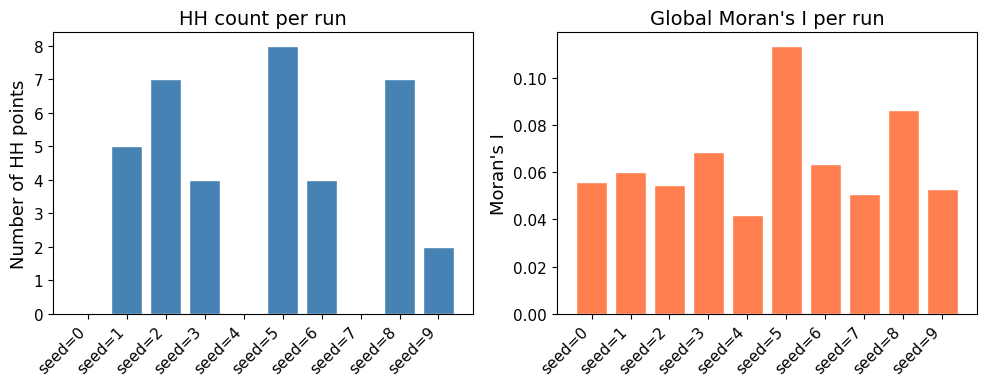

In [30]:
n_hh_per_run = [int(np.sum(r["HH_mask"])) for r in spatial_by_run]
run_labels = [r["run_dir"] for r in spatial_by_run]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.bar(range(len(n_hh_per_run)), n_hh_per_run, color="steelblue", edgecolor="white")
ax1.set_xticks(range(len(run_labels)))
ax1.set_xticklabels(run_labels, rotation=45, ha="right")
ax1.set_ylabel("Number of HH points")
ax1.set_title("HH count per run")

moran_per_run = [r["moran_i"] for r in spatial_by_run]
ax2.bar(range(len(moran_per_run)), moran_per_run, color="coral", edgecolor="white")
ax2.set_xticks(range(len(run_labels)))
ax2.set_xticklabels(run_labels, rotation=45, ha="right")
ax2.set_ylabel("Moran's I")
ax2.set_title("Global Moran's I per run")
plt.tight_layout()
fig.savefig(FIG_DIR / f"hh_moran_per_run_{DATASET}.pdf", bbox_inches="tight")
plt.show()

## Correlation: mean variance vs Moran's I per run

Plot mean variance (multiplicity) against global Moran's I (spatial clustering of variance) across runs.

- **Positive correlation:** More multiplicity → stronger spatial clustering of disagreement. Multiplicity concentrates in regions rather than being diffuse.
- **No (or weak) correlation:** Spatial structure of hotspots can exist even when overall multiplicity is small; the two are not simply coupled.

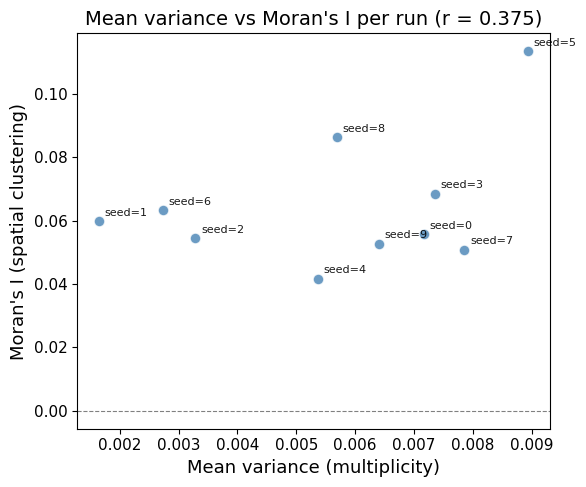

Positive correlation: more multiplicity tends to coincide with stronger spatial clustering.


In [31]:
corr_df = pd.DataFrame({
    "run": [r["run_dir"] for r in spatial_by_run],
    "mean_variance": [r["mean_variance"] for r in spatial_by_run],
    "moran_i": [r["moran_i"] for r in spatial_by_run],
})
r_pearson = np.corrcoef(corr_df["mean_variance"], corr_df["moran_i"])[0, 1]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(corr_df["mean_variance"], corr_df["moran_i"], s=60, alpha=0.8, color="steelblue", edgecolor="white")
for _, row in corr_df.iterrows():
    ax.annotate(row["run"], (row["mean_variance"], row["moran_i"]), fontsize=8, alpha=0.9, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Mean variance (multiplicity)")
ax.set_ylabel("Moran's I (spatial clustering)")
ax.set_title(f"Mean variance vs Moran's I per run (r = {r_pearson:.3f})")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
fig.savefig(FIG_DIR / f"variance_vs_moran_{DATASET}.pdf", bbox_inches="tight")
plt.show()

if r_pearson > 0.2:
    print("Positive correlation: more multiplicity tends to coincide with stronger spatial clustering.")
elif r_pearson < -0.2:
    print("Negative correlation: higher multiplicity tends to go with weaker spatial clustering.")
else:
    print("Weak or no correlation: spatial structure of hotspots can exist even when overall multiplicity is small.")

## Connected component analysis (hotspot regions)

For one run, extract HH connected components using the kNN graph and report region sizes. Uses `analysis.spatial.extract_hh_components`. The same W from `spatial_analysis` is used. The kNN adjacency is symmetrized before row-standardization, so connected components are interpreted on the undirected neighborhood structure.

In [32]:
# Use representative run for component analysis
r0 = spatial_by_run[rep_idx]
HH_mask = r0["HH_mask"]
W_pysal = r0["W"]
W_sparse = W_pysal.to_sparse() if hasattr(W_pysal, "to_sparse") else W_pysal.sparse

lisa_df = pd.DataFrame({
    "cluster": np.where(HH_mask, "HH", "NS"),
})
comp_id, components = extract_hh_components(lisa_df, W_sparse, min_size=5)

print(f"Run: {r0['run_dir']}")
print(f"HH points: {HH_mask.sum()}")
print(f"Connected components (min_size=5): {len(components)}")
for cid, inds in components.items():
    print(f"  Component {cid}: n = {len(inds)}")

Run: seed=3
HH points: 4
Connected components (min_size=5): 0


## Region persistence summary

Across runs, summarize number of HH components and largest component size (when available) to assess hotspot stability.

In [33]:
# Component summary (with stability metrics) was computed and saved in the HH stability cell above.
# Saved to: tables/hh_component_summary_{DATASET}.csv
print("Thesis-facing HH connected-component summary (per-run detail, min_size=5):")
display(hh_component_summary)
print(f"Mean n_components: {hh_component_summary['n_components'].mean():.2f}")
print(f"Mean max_component_size: {hh_component_summary['max_component_size'].mean():.2f}")


Thesis-facing HH connected-component summary (per-run detail, min_size=5):


,run,n_components,max_component_size,mean_hh_fraction,mean_jaccard,min_jaccard,max_jaccard,hh_support_size,hh_support_mean_f,hh_support_median_f,hh_support_bucket_00_02,hh_support_bucket_02_05,hh_support_bucket_05_08,hh_support_bucket_08_10,hh_support_bucket_00_02_frac,hh_support_bucket_02_05_frac,hh_support_bucket_05_08_frac,hh_support_bucket_08_10_frac,hh_core_to_support_ratio
0,seed=0,0,0,0.0185,0.161866,0.0,1.0,0.105,0.17619,0.1,18.0,2.0,1.0,0.0,0.857143,0.095238,0.047619,0.0,0.095238
1,seed=1,1,5,0.0185,0.161866,0.0,1.0,0.105,0.17619,0.1,18.0,2.0,1.0,0.0,0.857143,0.095238,0.047619,0.0,0.095238
2,seed=2,1,7,0.0185,0.161866,0.0,1.0,0.105,0.17619,0.1,18.0,2.0,1.0,0.0,0.857143,0.095238,0.047619,0.0,0.095238
3,seed=3,0,0,0.0185,0.161866,0.0,1.0,0.105,0.17619,0.1,18.0,2.0,1.0,0.0,0.857143,0.095238,0.047619,0.0,0.095238
4,seed=4,0,0,0.0185,0.161866,0.0,1.0,0.105,0.17619,0.1,18.0,2.0,1.0,0.0,0.857143,0.095238,0.047619,0.0,0.095238
5,seed=5,1,8,0.0185,0.161866,0.0,1.0,0.105,0.17619,0.1,18.0,2.0,1.0,0.0,0.857143,0.095238,0.047619,0.0,0.095238
6,seed=6,0,0,0.0185,0.161866,0.0,1.0,0.105,0.17619,0.1,18.0,2.0,1.0,0.0,0.857143,0.095238,0.047619,0.0,0.095238
7,seed=7,0,0,0.0185,0.161866,0.0,1.0,0.105,0.17619,0.1,18.0,2.0,1.0,0.0,0.857143,0.095238,0.047619,0.0,0.095238
8,seed=8,1,7,0.0185,0.161866,0.0,1.0,0.105,0.17619,0.1,18.0,2.0,1.0,0.0,0.857143,0.095238,0.047619,0.0,0.095238
9,seed=9,0,0,0.0185,0.161866,0.0,1.0,0.105,0.17619,0.1,18.0,2.0,1.0,0.0,0.857143,0.095238,0.047619,0.0,0.095238


Mean n_components: 0.40
Mean max_component_size: 2.70


After constructing the symmetrized kNN weights/graph W for X_test, compute the number of connected components and the largest component size. The kNN graph is symmetrized by default in spatial_analysis for undirected analysis.

In [34]:
# Graph connectivity diagnostic using the representative run's kNN weights
W_rep = ensure_spatial_weights(spatial_by_run[rep_idx], dataset_dir / spatial_by_run[rep_idx]["run_dir"])
W_sparse_rep = W_rep.to_sparse() if hasattr(W_rep, "to_sparse") else W_rep.sparse

# Symmetrize for undirected connectivity
W_sym = W_sparse_rep + W_sparse_rep.T
W_sym = (W_sym > 0).astype(int)

n_components, labels = sparse_connected_components(W_sym, directed=False)
component_sizes = np.bincount(labels)
largest_component = int(component_sizes.max())
n_test = W_sym.shape[0]

print(f"Graph connectivity diagnostics (run: {spatial_by_run[rep_idx]['run_dir']}, k={k_nn}):")
print(f"  kNN graph symmetrized to undirected for connectivity check")
print(f"  Number of connected components: {n_components}")
print(f"  Largest component size: {largest_component} ({largest_component/n_test:.1%} of {n_test} test points)")
if n_components > 1:
    print(f"  Component size distribution: {sorted(component_sizes, reverse=True)}")
else:
    print(f"  Graph is fully connected.")

Graph connectivity diagnostics (run: seed=3, k=30):
  kNN graph symmetrized to undirected for connectivity check
  Number of connected components: 1
  Largest component size: 200 (100.0% of 200 test points)
  Graph is fully connected.


## Family-wise Moran/LISA comparison

Compute Moran's I and HH counts for per-family Rashomon sets (top-K=25 per family) and compare to global. This helps determine whether multiplicity hotspots originate from inter-family or intra-family diversity.

Using per-family CSV: C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results\compas\per_family_spatial_aggregated.csv
Using global summary CSV: C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results\compas\summary_per_run.csv
compas: Global mean HH = 129.7, Global mean Moran's I = 0.2100



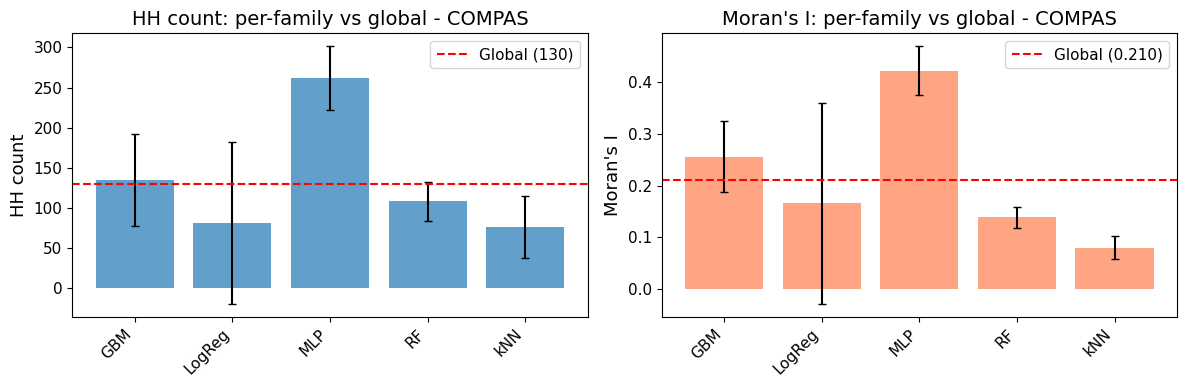

Using per-family CSV: C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results\german\per_family_spatial_aggregated.csv
Using global summary CSV: C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results\german\summary_per_run.csv
german: Global mean HH = 6.0, Global mean Moran's I = 0.0876



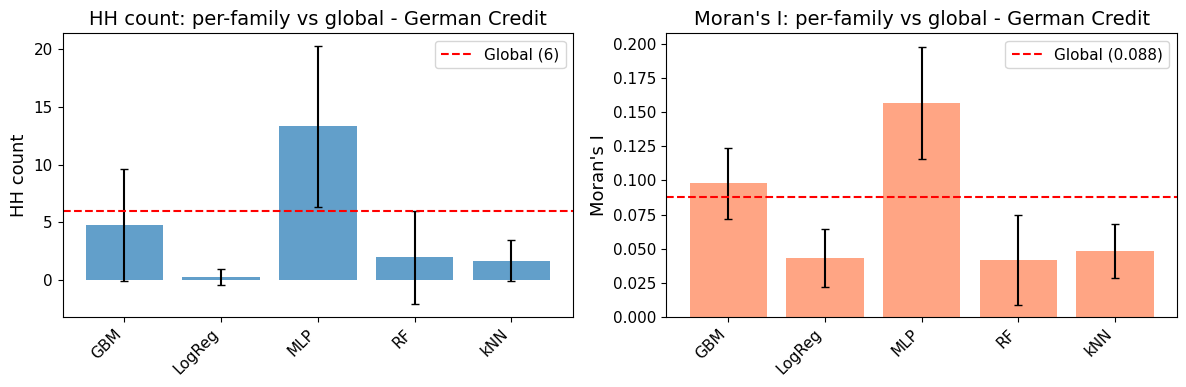

Using per-family CSV: C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results\adult\per_family_spatial_aggregated.csv
Using global summary CSV: C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results\adult\summary_per_run.csv
adult: Global mean HH = 630.3, Global mean Moran's I = 0.0749



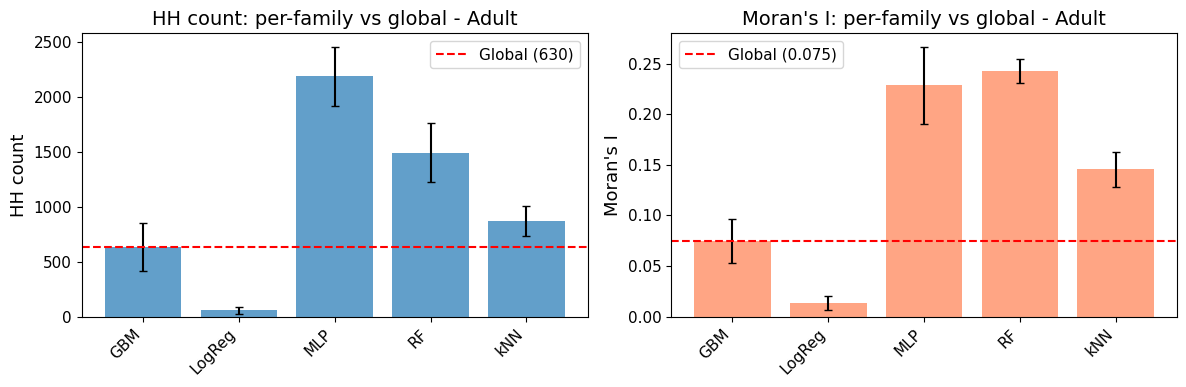

In [35]:
from pathlib import Path

DATASETS_FIG4 = ["compas", "german", "adult"]

for dataset in DATASETS_FIG4:
    per_family_path = RAW_RESULTS / dataset / "per_family_spatial_aggregated.csv"
    summary_path = RAW_RESULTS / dataset / "summary_per_run.csv"

    print(f"Using per-family CSV: {per_family_path}")
    print(f"Using global summary CSV: {summary_path}")

    if not per_family_path.exists():
        raise FileNotFoundError(f"Missing per-family CSV: {per_family_path}")
    if not summary_path.exists():
        raise FileNotFoundError(f"Missing summary CSV: {summary_path}")

    fam_agg = pd.read_csv(per_family_path)
    summary_df = pd.read_csv(summary_path)

    if "family" not in fam_agg.columns:
        raise ValueError("per_family_spatial_aggregated.csv must contain a 'family' column")

    glob_mean_hh = summary_df["n_hh"].mean()
    glob_mean_moran = summary_df["moran_i"].mean()

    print(f"{dataset}: Global mean HH = {glob_mean_hh:.1f}, Global mean Moran's I = {glob_mean_moran:.4f}")
    print()

    fam_agg = fam_agg.sort_values("family")
    families = fam_agg["family"].values
    x = range(len(families))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.bar(x, fam_agg["n_hh_mean"], yerr=fam_agg["n_hh_std"], capsize=3, alpha=0.7)
    ax1.axhline(glob_mean_hh, color="red", ls="--", label=f"Global ({glob_mean_hh:.0f})")
    ax1.set_xticks(list(x))
    ax1.set_xticklabels(families, rotation=45, ha="right")
    ax1.set_ylabel("HH count")
    ax1.set_title(f"HH count: per-family vs global - {display_dataset_name(dataset)}")
    ax1.legend()

    ax2.bar(x, fam_agg["moran_i_mean"], yerr=fam_agg["moran_i_std"], capsize=3, alpha=0.7, color="coral")
    ax2.axhline(glob_mean_moran, color="red", ls="--", label=f"Global ({glob_mean_moran:.3f})")
    ax2.set_xticks(list(x))
    ax2.set_xticklabels(families, rotation=45, ha="right")
    ax2.set_ylabel("Moran's I")
    ax2.set_title(f"Moran's I: per-family vs global - {display_dataset_name(dataset)}")
    ax2.legend()

    fig.tight_layout()
    fig.savefig(FIG_DIR / f"family_vs_global_spatial_{dataset}.pdf", bbox_inches="tight")
    plt.show()


## Variance vs Conflict hotspots

Side-by-side PCA plots comparing variance-based HH and conflict-based HH for the representative run. Also shows overlap vs XOR (symmetric difference) and reports Jaccard overlap.

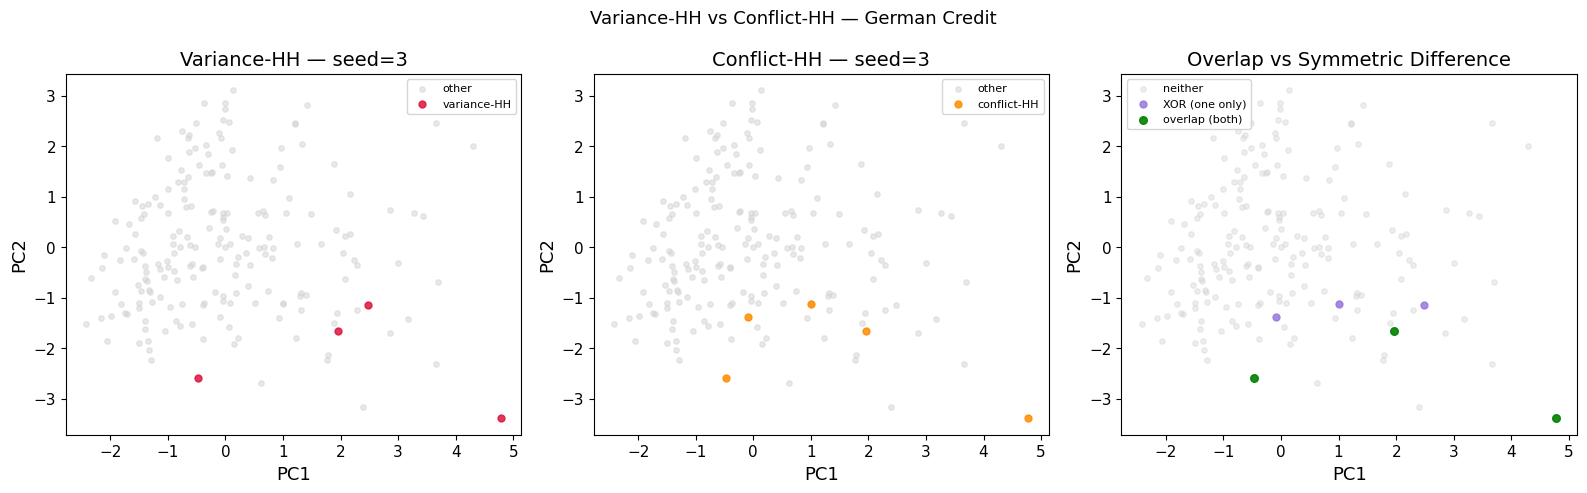

Variance-HH vs Conflict-HH Jaccard for seed=3:
  |var-HH| = 4, |conf-HH| = 5
  |intersection| = 3, |union| = 6
  Jaccard = 0.5000


In [36]:
# Conflict-HH vs variance-HH for the representative run
r_rep = spatial_by_run[rep_idx]
var_hh = r_rep["HH_mask"]
conf_hh = r_rep.get("conflict_HH_mask", np.zeros(len(var_hh), dtype=bool))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: variance-HH
axes[0].scatter(coords[~var_hh, 0], coords[~var_hh, 1], c="lightgray", s=15, alpha=0.5, label="other")
axes[0].scatter(coords[var_hh, 0], coords[var_hh, 1], c="crimson", s=25, alpha=0.85, label="variance-HH")
axes[0].set_title(f"Variance-HH — {r_rep['run_dir']}")
axes[0].set_xlabel("PC1" if n_features > 2 else "Feature 1")
axes[0].set_ylabel("PC2" if n_features > 2 else "Feature 2")
axes[0].legend(fontsize=8)

# Panel B: conflict-HH
axes[1].scatter(coords[~conf_hh, 0], coords[~conf_hh, 1], c="lightgray", s=15, alpha=0.5, label="other")
axes[1].scatter(coords[conf_hh, 0], coords[conf_hh, 1], c="darkorange", s=25, alpha=0.85, label="conflict-HH")
axes[1].set_title(f"Conflict-HH — {r_rep['run_dir']}")
axes[1].set_xlabel("PC1" if n_features > 2 else "Feature 1")
axes[1].set_ylabel("PC2" if n_features > 2 else "Feature 2")
axes[1].legend(fontsize=8)

# Panel C: overlap vs XOR
overlap = var_hh & conf_hh
xor = var_hh ^ conf_hh
rest = ~(var_hh | conf_hh)
axes[2].scatter(coords[rest, 0], coords[rest, 1], c="lightgray", s=15, alpha=0.4, label="neither")
axes[2].scatter(coords[xor, 0], coords[xor, 1], c="mediumpurple", s=25, alpha=0.8, label="XOR (one only)")
axes[2].scatter(coords[overlap, 0], coords[overlap, 1], c="green", s=30, alpha=0.9, label="overlap (both)")
axes[2].set_title("Overlap vs Symmetric Difference")
axes[2].set_xlabel("PC1" if n_features > 2 else "Feature 1")
axes[2].set_ylabel("PC2" if n_features > 2 else "Feature 2")
axes[2].legend(fontsize=8)

fig.suptitle(f"Variance-HH vs Conflict-HH — {display_dataset_name(DATASET)}", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / f"var_vs_conflict_hh_{DATASET}.pdf", bbox_inches="tight")
plt.show()

# Jaccard overlap
union_count = int(np.sum(var_hh | conf_hh))
inter_count = int(np.sum(var_hh & conf_hh))
J_vc = inter_count / union_count if union_count > 0 else 0.0
print(f"Variance-HH vs Conflict-HH Jaccard for {r_rep['run_dir']}:")
print(f"  |var-HH| = {int(np.sum(var_hh))}, |conf-HH| = {int(np.sum(conf_hh))}")
print(f"  |intersection| = {inter_count}, |union| = {union_count}")
print(f"  Jaccard = {J_vc:.4f}")

## HH overlap stability

Pairwise Jaccard overlaps between HH masks across all seed pairs for both variance-HH and conflict-HH. Also cross Jaccard (variance-HH vs conflict-HH) per seed.

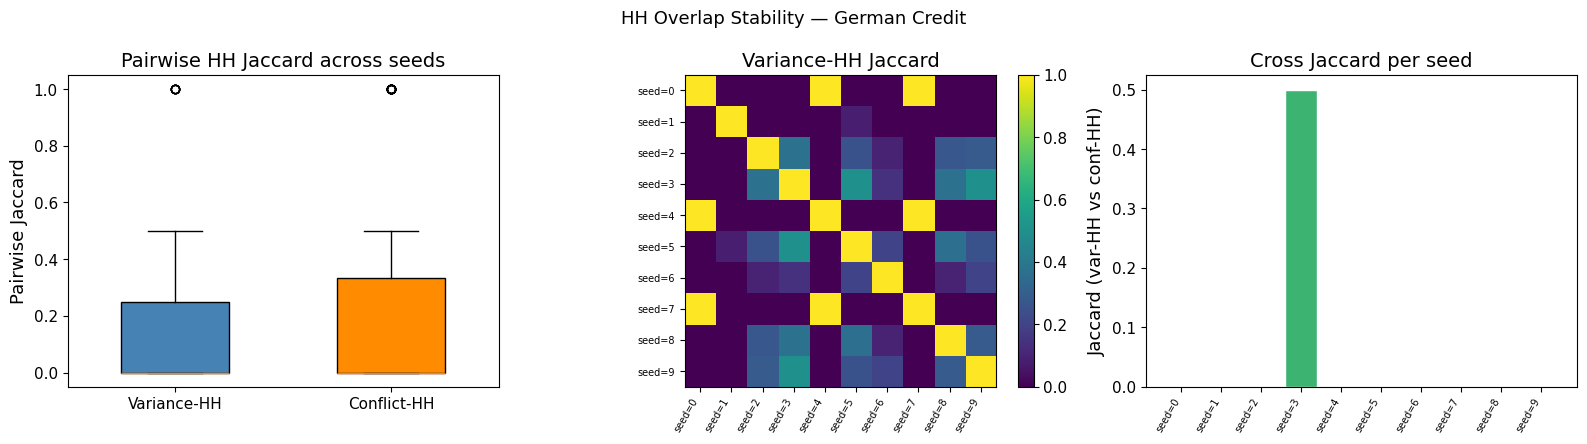

Variance-HH pairwise Jaccard: mean=0.162, std=0.268
Conflict-HH pairwise Jaccard: mean=0.246, std=0.413
Cross Jaccard (var vs conf) per seed: mean=0.050, std=0.150


In [37]:
from analysis.stability import hh_jaccard_matrix

# Variance-HH pairwise Jaccard (already computed as J in cell 6)
var_hh_masks = [r["HH_mask"] for r in spatial_by_run]
J_var = hh_jaccard_matrix(var_hh_masks)

# Conflict-HH pairwise Jaccard
conf_hh_masks = [r.get("conflict_HH_mask", np.zeros(len(r["HH_mask"]), dtype=bool)) for r in spatial_by_run]
J_conf = hh_jaccard_matrix(conf_hh_masks)

# Cross: variance-HH vs conflict-HH per seed
cross_jaccards = []
for r in spatial_by_run:
    v = r["HH_mask"]
    c = r.get("conflict_HH_mask", np.zeros(len(v), dtype=bool))
    union_c = int(np.sum(v | c))
    j = int(np.sum(v & c)) / union_c if union_c > 0 else 0.0
    cross_jaccards.append(j)

n_seeds = len(spatial_by_run)
run_labels = [r["run_dir"] for r in spatial_by_run]

# Extract off-diagonal values
off_diag_var = J_var[~np.eye(n_seeds, dtype=bool)]
off_diag_conf = J_conf[~np.eye(n_seeds, dtype=bool)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# A) Boxplot of pairwise Jaccard (variance-HH and conflict-HH)
bp = axes[0].boxplot([off_diag_var, off_diag_conf], tick_labels=["Variance-HH", "Conflict-HH"],
                     patch_artist=True, widths=0.5)
bp["boxes"][0].set_facecolor("steelblue")
bp["boxes"][1].set_facecolor("darkorange")
axes[0].set_ylabel("Pairwise Jaccard")
axes[0].set_title("Pairwise HH Jaccard across seeds")

# B) Jaccard heatmap for variance-HH
im1 = axes[1].imshow(J_var, cmap="viridis", vmin=0, vmax=1)
axes[1].set_xticks(range(n_seeds)); axes[1].set_xticklabels(run_labels, rotation=60, ha="right", fontsize=7)
axes[1].set_yticks(range(n_seeds)); axes[1].set_yticklabels(run_labels, fontsize=7)
axes[1].set_title("Variance-HH Jaccard")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# C) Cross Jaccard per seed
axes[2].bar(range(n_seeds), cross_jaccards, color="mediumseagreen", edgecolor="white")
axes[2].set_xticks(range(n_seeds))
axes[2].set_xticklabels(run_labels, rotation=60, ha="right", fontsize=7)
axes[2].set_ylabel("Jaccard (var-HH vs conf-HH)")
axes[2].set_title("Cross Jaccard per seed")

fig.suptitle(f"HH Overlap Stability — {display_dataset_name(DATASET)}", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / f"hh_jaccard_distributions_{DATASET}.pdf", bbox_inches="tight")
plt.show()

print(f"Variance-HH pairwise Jaccard: mean={off_diag_var.mean():.3f}, std={off_diag_var.std():.3f}")
print(f"Conflict-HH pairwise Jaccard: mean={off_diag_conf.mean():.3f}, std={off_diag_conf.std():.3f}")
print(f"Cross Jaccard (var vs conf) per seed: mean={np.mean(cross_jaccards):.3f}, std={np.std(cross_jaccards):.3f}")

## Cross-seed HH frequency support

Low pairwise Jaccard between HH masks does not rule out a stable *support* of occasionally selected HH points. For each benchmark dataset, we aggregate variance-HH masks across seeds on the fixed test set and report point-level support diagnostics via `summarize_hh_stability`:

1. **Pairwise Jaccard** — mean, min, and max off-diagonal Jaccard between HH masks across seed pairs.
2. **HH support size** — fraction of test points ever classified HH, \(|\\{i : f_i > 0\\}| / N\).
3. **Frequency on support** — mean and median of per-point HH frequency \(f_i\) among points with \(f_i > 0\).
4. **Support buckets** — counts (and fractions of support) in \((0,0.2], (0.2,0.5], (0.5,0.8], (0.8,1]\).
5. **Core-to-support ratio** — share of the support with \(f_i \ge 0.5\) (seed-persistent core).

Connected-component structure for a representative run is analysed separately in the next section (regionality metrics).

In [38]:
DATASETS = ["compas", "german", "adult"]

# Defaults if this cell runs before the cell that sets RESULTS_DIR, K
if "RESULTS_DIR" not in dir() or not isinstance(RESULTS_DIR if "RESULTS_DIR" in dir() else None, Path):
    try:
        from thesis_layout import RAW_RESULTS as _RR
        RESULTS_DIR = _RR
    except Exception:
        RESULTS_DIR = Path("results")
if "K" not in dir():
    K = 25

# Build all_runs if not already defined
all_runs = globals().get("all_runs", None)
if all_runs is None:
    all_runs = []
    for _ds in DATASETS:
        dataset_dir = RESULTS_DIR / _ds
        run_dirs_ds = get_run_dirs(dataset_dir)
        if not run_dirs_ds:
            continue
        for run_dir in run_dirs_ds:
            n_cand = len(load_meta(run_dir))
            K_actual = min(K, n_cand)
            X_test = get_transformed_test_features(run_dir, _ds)
            res = run_spatial(run_dir, X_test, K=K_actual, k=K_NN_BY_DATASET[_ds], seed=42)
            r = dict(res)
            r["dataset"] = _ds
            r["X_test"] = X_test
            all_runs.append(r)

for ds in DATASETS:
    print(f"\n{'='*60}")
    print(f"  Cross-seed HH frequency support: {ds}")
    print(f"{'='*60}")

    ds_runs = [r for r in all_runs if r["dataset"] == ds]
    if not ds_runs:
        print("  (no runs)")
        continue

    hh_masks_ds = [r["HH_mask"] for r in ds_runs]
    summary = summarize_hh_stability(hh_masks_ds)

    print("\n  Point-level stability:")
    print(f"    Mean Jaccard (pointwise):        {summary['mean_jaccard']:.4f}")
    print(f"    Min Jaccard:                     {summary['min_jaccard']:.4f}")
    print(f"    Max Jaccard:                     {summary['max_jaccard']:.4f}")
    print(f"    HH support |{{i : f_i > 0}}|/N:   {summary['hh_support_size']:.4f}")
    print(
        f"    On support: mean f_i = {summary['hh_support_mean_f']:.4f}, "
        f"median = {summary['hh_support_median_f']:.4f}"
    )
    print(
        "    Support buckets (counts):",
        int(summary["hh_support_bucket_00_02"]),
        int(summary["hh_support_bucket_02_05"]),
        int(summary["hh_support_bucket_05_08"]),
        int(summary["hh_support_bucket_08_10"]),
    )
    print(
        "    Support buckets (frac of support):",
        f"{summary['hh_support_bucket_00_02_frac']:.3f},",
        f"{summary['hh_support_bucket_02_05_frac']:.3f},",
        f"{summary['hh_support_bucket_05_08_frac']:.3f},",
        f"{summary['hh_support_bucket_08_10_frac']:.3f}",
    )
    print(
        f"    Core-to-support (f_i>=0.5)/support: "
        f"{summary['hh_core_to_support_ratio']:.4f}"
    )


  Cross-seed HH frequency support: compas

  Point-level stability:
    Mean Jaccard (pointwise):        0.3639
    Min Jaccard:                     0.1411
    Max Jaccard:                     0.6105
    HH support |{i : f_i > 0}|/N:   0.2169
    On support: mean f_i = 0.3597, median = 0.2000
    Support buckets (counts): 176 57 50 30
    Support buckets (frac of support): 0.562, 0.182, 0.160, 0.096
    Core-to-support (f_i>=0.5)/support: 0.2780

  Cross-seed HH frequency support: german

  Point-level stability:
    Mean Jaccard (pointwise):        0.1619
    Min Jaccard:                     0.0000
    Max Jaccard:                     1.0000
    HH support |{i : f_i > 0}|/N:   0.1050
    On support: mean f_i = 0.1762, median = 0.1000
    Support buckets (counts): 18 2 1 0
    Support buckets (frac of support): 0.857, 0.095, 0.048, 0.000
    Core-to-support (f_i>=0.5)/support: 0.0952

  Cross-seed HH frequency support: adult

  Point-level stability:
    Mean Jaccard (pointwise):     

## Regionality metrics of HH hotspots

To summarize the structure of multiplicity regions, we compute regionality metrics based on connected components of HH hotspots.

These metrics describe whether hotspots form a few large coherent regions or many small fragmented clusters.

In [39]:
from thesis_layout import apply_thesis_plot_style, display_dataset_name

apply_thesis_plot_style()

if not isinstance(components, dict):
    raise TypeError(f"`components` should be a dict, got {type(components)}")

component_sizes = (
    np.array([len(v) for v in components.values()], dtype=int)
    if len(components) > 0
    else np.array([], dtype=int)
)

n_hh_points = int(HH_mask.sum())

regionality_df = pd.DataFrame([{
    "n_hh_points": n_hh_points,
    "n_components": int(len(component_sizes)),
    "largest_component_size": int(component_sizes.max()) if len(component_sizes) else 0,
    "mean_component_size": float(component_sizes.mean()) if len(component_sizes) else 0.0,
    "median_component_size": float(np.median(component_sizes)) if len(component_sizes) else 0.0,
    "share_in_largest_component": (
        float(component_sizes.max() / n_hh_points)
        if n_hh_points > 0 and len(component_sizes)
        else 0.0
    ),
    "fragmentation_index": (
        float(len(component_sizes) / n_hh_points)
        if n_hh_points > 0
        else 0.0
    ),
}])

print("component_sizes:", component_sizes.tolist())
display(regionality_df)

# optional bar plot of component sizes
if len(component_sizes) > 0:
    sizes_sorted = np.sort(component_sizes)[::-1]

    plt.figure(figsize=(5.5, 3.8))
    plt.bar(range(1, len(sizes_sorted) + 1), sizes_sorted)
    plt.xlabel("Component rank")
    plt.ylabel("Component size")
    plt.title(f"HH component sizes — {display_dataset_name(DATASET)}")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No HH components found.")

component_sizes: []


,n_hh_points,n_components,largest_component_size,mean_component_size,median_component_size,share_in_largest_component,fragmentation_index
0,4,0,0,0.0,0.0,0.0,0.0


No HH components found.
